<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Decision_Tree/DecisonTree_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 151 (delta 47), reused 21 (delta 2), pack-reused 18 (from 2)
Receiving objects: 100% (151/151), 209.68 MiB | 23.88 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Updating files: 100% (45/45), done.
Filtering content: 100% (14/14), 1.29 GiB | 51.01 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pickle

In [ ]:
def unpickle(file) :
    with open(file, 'rb') as f:
        return pickle.load(f)

In [ ]:
train_labels = unpickle('PreProcessedData/Labels_train.pkl')
test_labels = unpickle('PreProcessedData/Labels_test.pkl')

resnet_train_data = unpickle('PreProcessedData/Resnet_train.pkl')
resnet_test_data = unpickle('PreProcessedData/Resnet_test.pkl')

train_ResNetData = np.array(resnet_train_data)
test_ResNetData = np.array(resnet_test_data)

In [ ]:
%cd ..

/content


In [ ]:
quicknet_train_data = unpickle('quicknet_train.pkl')
quicknet_test_data = unpickle('quicknet_test.pkl')

In [ ]:
X_train = [resnet_train_data, quicknet_train_data]
X_test = [resnet_test_data, quicknet_test_data]
y_train = [train_labels, train_labels]
y_test = [test_labels, test_labels]

In [ ]:
X_val = []
y_val = []
# y_ = y_train # Remove this line
y_trains = []
for i in range(2):
  X_train[i], x_val, y_train[i], Y_val = train_test_split(X_train[i], y_train[i], test_size=0.2, random_state=42) # Change y_ to y_train[i]
  X_val.append(x_val)
  y_val.append(Y_val)
  y_trains.append(y_train[i]) # This line can be removed if y_train is not used later

# y_train = y_trains # Remove this line if y_train is not used later

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from tqdm import tqdm

def trainDecisionTree(X_train, y_train, max_depth, criterion):
    '''
      Fits a decision tree for the given data and impurity
    '''
    tree = DecisionTreeClassifier(criterion = criterion, max_depth=max_depth)
    tree.fit(X_train, y_train)
    return tree

def RunningMaxDepth(X_train, y_train, X_val, y_val, criterion) :
    '''
      Finds the max_depth of the tree, that is the depth for which the tree is
      fully grown(train accuracy approaches 100%)
    '''
    print('Building the Fully grown tree')
    trees = []
    max_depth = 100
    train_accuracies = []
    validation_accuracies = []
    for depth in tqdm(range(1, max_depth)):
        tree = trainDecisionTree(X_train, y_train, depth, criterion)
        train_accuracy = tree.score(X_train, y_train)
        validation_accuracy = tree.score(X_val, y_val)
        train_accuracies.append(train_accuracy)
        validation_accuracies.append(validation_accuracy)
        trees.append(tree)
        if train_accuracy >= 0.99 :
            max_depth = depth
            break
    return max_depth, train_accuracies, validation_accuracies, trees

def plot_accuracies_vs_depths(depths, train_accuracies, validation_accuracies, title_string):
    '''
        Helping function to plot accuracy vs depth plots
    '''
    plt.figure(figsize=(8, 5))
    plt.plot(depths, train_accuracies, marker='o', linestyle='--', color='r', label='Training Accuracy')
    plt.plot(depths, validation_accuracies, marker='o', linestyle='-', color='b', label='Validation Accuracy')
    plt.xlabel('Depth')
    plt.ylabel('Accuracy')
    plt.title('Depth vs Accuracy ' + title_string)
    plt.xticks(depths)
    plt.legend()
    plt.show()

def DecisionTree(X_train, y_train, criterion, X_val, y_val):

    Max_depth, train_accuracies, validation_accuracies, Trees = RunningMaxDepth(X_train, y_train,X_val, y_val, criterion)

    optimal_depth = validation_accuracies.index(max(validation_accuracies)) + 1

    optimal_tree = Trees[optimal_depth-1]

    return optimal_tree, optimal_depth, train_accuracies, validation_accuracies,Max_depth


def predict(tree, X_test) :

    return tree.predict(X_test)

def testAccuracy(LabelsPrediction, LabelsActual) :

    return np.sum(LabelsPrediction == LabelsActual ) / len(LabelsActual)

In [ ]:
OptimalTree_ResNet , OptimalDepth_ResNet, TrainAccuracies_ResNet, ValidationAccuracies_ResNet, MaxDepth_ResNet = DecisionTree(X_train[0],y_trains[0],'entropy',X_val[0],y_val[0])

Building the Fully grown tree


 15%|█▌        | 15/99 [1:12:43<6:47:18, 290.93s/it]


In [ ]:
y_pred = predict(OptimalTree_ResNet, X_test[0])
print(testAccuracy(y_pred, y_test[0]))

0.6734


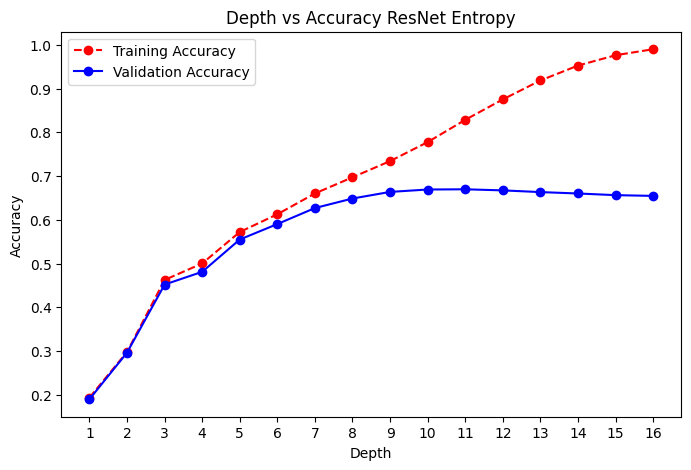

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_ResNet+1), TrainAccuracies_ResNet, ValidationAccuracies_ResNet, 'ResNet Entropy')

In [ ]:
print(OptimalDepth_ResNet, TrainAccuracies_ResNet, ValidationAccuracies_ResNet)

11 [0.19335, 0.297725, 0.462475, 0.500125, 0.5721, 0.612675, 0.6603, 0.697225, 0.734275, 0.777725, 0.82865, 0.875375, 0.918675, 0.95275, 0.976425, 0.9902] [0.1896, 0.2962, 0.4519, 0.481, 0.5549, 0.5903, 0.6269, 0.6487, 0.6638, 0.6693, 0.6698, 0.6673, 0.6634, 0.6602, 0.6564, 0.6547]


In [ ]:
OptimalTree_quicknet , OptimalDepth_quicknet, TrainAccuracies_quicknet, ValidationAccuracies_quicknet, MaxDepth_quicknet = DecisionTree(X_train[1],y_trains[1],'gini',X_val[1],y_val[1])

Building the Fully grown tree


 31%|███▏      | 31/99 [03:55<08:36,  7.60s/it]


In [ ]:
y_pred_g = predict(OptimalTree_quicknet, X_test[1])
print(testAccuracy(y_pred_g, y_test[1]))

0.5802


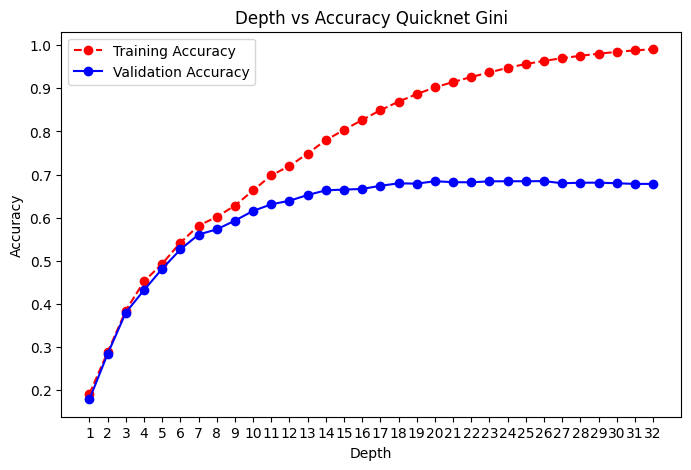

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_quicknet+1), TrainAccuracies_quicknet, ValidationAccuracies_quicknet, 'Quicknet Gini')

In [ ]:
print(OptimalDepth_quicknet, TrainAccuracies_quicknet, ValidationAccuracies_quicknet)

26 [0.1915, 0.287825, 0.384525, 0.452275, 0.4932, 0.541925, 0.581575, 0.6017, 0.628025, 0.663225, 0.69835, 0.71985, 0.7489, 0.779975, 0.80365, 0.8268, 0.849375, 0.8692, 0.8868, 0.90225, 0.9148, 0.926475, 0.937025, 0.9478, 0.95655, 0.9638, 0.970075, 0.9757, 0.980475, 0.984675, 0.988175, 0.990875] [0.1788, 0.284, 0.3799, 0.4319, 0.4814, 0.5262, 0.5609, 0.5729, 0.5932, 0.6157, 0.631, 0.6393, 0.6526, 0.6635, 0.6652, 0.6667, 0.674, 0.6797, 0.679, 0.6846, 0.6824, 0.6821, 0.6843, 0.6846, 0.6845, 0.6849, 0.6799, 0.6811, 0.6813, 0.6799, 0.6784, 0.6784]


In [ ]:
OptimalTree_ResNet_ , OptimalDepth_ResNet_, TrainAccuracies_ResNet_, ValidationAccuracies_ResNet_, MaxDepth_ResNet_ = DecisionTree(X_train[0],y_trains[0],'gini',X_val[0],y_val[0])

Building the Fully grown tree


 25%|██▌       | 25/99 [1:22:21<4:03:46, 197.65s/it]


In [ ]:
y_pred_ = predict(OptimalTree_ResNet_, X_test[0])
print(testAccuracy(y_pred_, y_test[0]))

0.6665


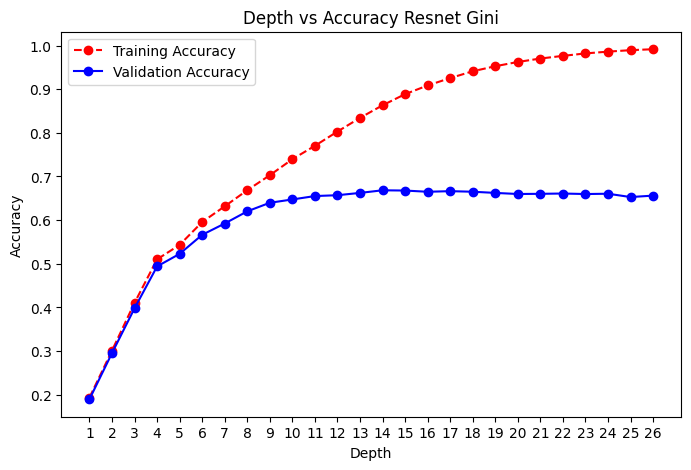

14 [0.1933, 0.301, 0.4104, 0.510125, 0.543225, 0.595625, 0.6316, 0.6685, 0.7028, 0.739525, 0.770225, 0.80285, 0.8342, 0.863025, 0.8886, 0.90845, 0.9254, 0.940975, 0.95255, 0.962275, 0.970175, 0.976275, 0.981875, 0.985975, 0.98935, 0.9915] [0.1896, 0.2953, 0.398, 0.4939, 0.5227, 0.5663, 0.5922, 0.6201, 0.6397, 0.6473, 0.6551, 0.657, 0.6623, 0.6683, 0.6677, 0.6649, 0.6663, 0.665, 0.6623, 0.6598, 0.6602, 0.6609, 0.6597, 0.6604, 0.6528, 0.6561]


In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_ResNet_+1), TrainAccuracies_ResNet_, ValidationAccuracies_ResNet_, 'Resnet Gini')
print(OptimalDepth_ResNet_, TrainAccuracies_ResNet_, ValidationAccuracies_ResNet_)

In [ ]:
OptimalTree_quicknet_ , OptimalDepth_quicknet_, TrainAccuracies_quicknet_, ValidationAccuracies_quicknet_, MaxDepth_quicknet_ = DecisionTree(X_train[1],y_trains[1],'entropy',X_val[1],y_val[1])

Building the Fully grown tree


 22%|██▏       | 22/99 [03:30<12:17,  9.57s/it]


In [ ]:
y_pred_g_ = predict(OptimalTree_quicknet_, X_test[1])
print(testAccuracy(y_pred_g_, y_test[1]))

0.5748


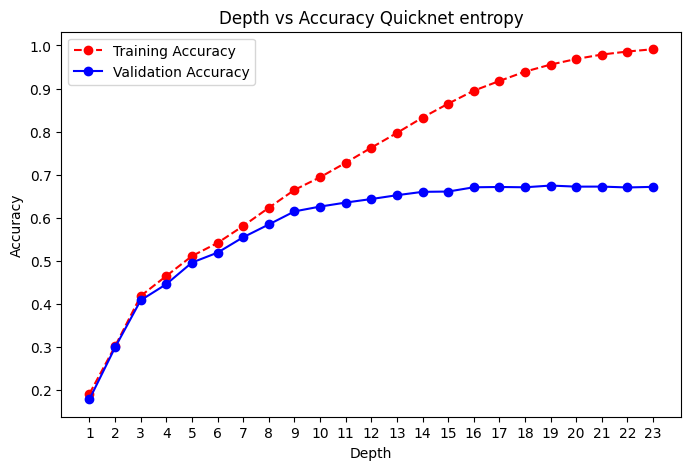

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_quicknet_+1), TrainAccuracies_quicknet_, ValidationAccuracies_quicknet_, 'Quicknet entropy')

In [ ]:
print(OptimalDepth_quicknet_, TrainAccuracies_quicknet_, ValidationAccuracies_quicknet_)

19 [0.1915, 0.3018, 0.4185, 0.464975, 0.51115, 0.541625, 0.580975, 0.62325, 0.66465, 0.694075, 0.727625, 0.762725, 0.796925, 0.8326, 0.86485, 0.895025, 0.917575, 0.93925, 0.95565, 0.96865, 0.97895, 0.98595, 0.9913] [0.1788, 0.299, 0.4085, 0.4459, 0.496, 0.5191, 0.5548, 0.5845, 0.6148, 0.626, 0.6353, 0.6435, 0.6524, 0.6602, 0.6609, 0.6708, 0.6715, 0.6708, 0.6748, 0.6723, 0.6724, 0.6704, 0.6718]
